# RL-10 : Reward Shaping et Curriculum Learning

**Notebook : 10/13** | **Duree** : 45-50 min | **Kernel** : Python 3

Dans les notebooks precedents, l'agent apprenait a partir du signal de recompense brut de l'environnement.
Mais que se passe-t-il quand la recompense est **sparse** (nulle partout sauf au but) ? L'agent peut mettre
des centaines d'episodes a trouver le but par hasard, puis des centaines d'autres pour apprendre le chemin.

Ce notebook presente trois techniques pour accelerer l'apprentissage :

1. **Reward shaping** : modifier le signal de recompense pour guider l'agent (sans changer la politique optimale !)
2. **Curriculum learning** : commencer par des taches faciles et augmenter progressivement la difficulte
3. **Analyse theorique** : pourquoi le potential-based shaping (Ng et al., 1999) garantit l'invariance de la politique

**Prerequis** : Notebooks 5 (MDP, Q-Learning) et 8 (model-based RL, planification).


## 1. Environnement : Labyrinthe Sparse

Un labyrinthe 8x8 avec des murs internes. La recompense est **sparse** : -1 par pas, 0 au but.
L'agent commence en bas a gauche, le but est en haut a droite (distance Manhattan = 14 pas).


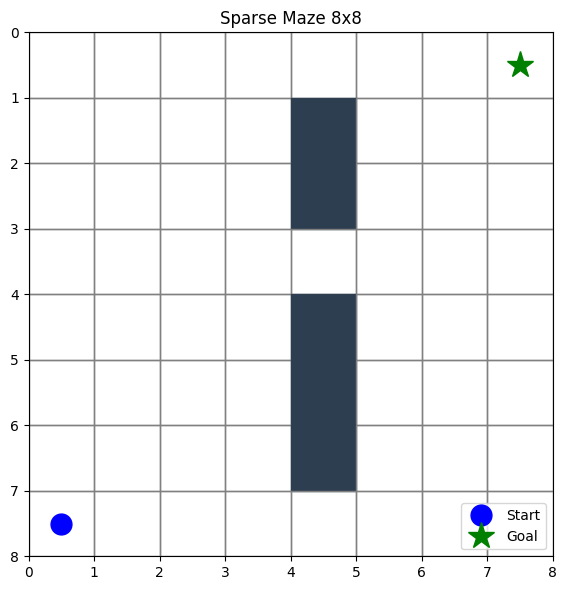

Distance Manhattan optimale : 14 pas


In [1]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
ALPHA, GAMMA, EPSILON = 0.1, 0.99, 0.1
MAX_STEPS = 500
ACTIONS = [(-1, 0), (1, 0), (0, -1), (0, 1)]  # haut, bas, gauche, droite

class SparseMaze:
    """Labyrinthe 8x8 avec reward sparse."""
    def __init__(self):
        self.height, self.width = 8, 8
        self.start = (7, 0)
        self.goal = (0, 7)
        self.walls = set()
        for r in range(1, 7):
            if r != 3:  # passage au milieu
                self.walls.add((r, 4))
        self.n_states = self.height * self.width
        self.n_actions = 4

    def idx(self, s):
        return s[0] * self.width + s[1]

    def reset(self):
        return self.start

    def step(self, s, a):
        dr, dc = ACTIONS[a]
        r2, c2 = s[0] + dr, s[1] + dc
        if not (0 <= r2 < self.height and 0 <= c2 < self.width) or (r2, c2) in self.walls:
            r2, c2 = s
        s2 = (r2, c2)
        if s2 == self.goal:
            return s2, 0.0, True
        return s2, -1.0, False

    def manhattan(self, s):
        """Distance de Manhattan au but."""
        return abs(s[0] - self.goal[0]) + abs(s[1] - self.goal[1])

def epsilon_greedy(Q, s_idx, n_actions, eps, rng):
    if rng.random() < eps:
        return rng.integers(n_actions)
    q = Q[s_idx]
    return rng.choice(np.flatnonzero(q == q.max()))

def plot_maze(env, title="Sparse Maze 8x8"):
    fig, ax = plt.subplots(figsize=(6, 6))
    for r in range(env.height):
        for c in range(env.width):
            if (r, c) in env.walls:
                ax.add_patch(plt.Rectangle((c, r), 1, 1, color='#2c3e50'))
            else:
                ax.add_patch(plt.Rectangle((c, r), 1, 1, fill=False, edgecolor='gray'))
    ax.plot(env.start[1] + 0.5, env.start[0] + 0.5, 'bo', ms=15, label='Start')
    ax.plot(env.goal[1] + 0.5, env.goal[0] + 0.5, 'g*', ms=20, label='Goal')
    ax.set_xlim(0, env.width); ax.set_ylim(env.height, 0)
    ax.set_title(title); ax.legend(loc='lower right')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

env = SparseMaze()
plot_maze(env)
print(f"Distance Manhattan optimale : {env.manhattan(env.start)} pas")


## 2. Q-Learning avec Reward Shaping

### Principe du Reward Shaping

On remplace la recompense $r$ par $r + F(s, a, s')$ ou $F$ est une fonction de **shaping**.
Le risque : si $F$ est mal choisie, la politique optimale peut changer !

### Potential-Based Shaping (Ng et al., 1999)

Si $F(s, s') = \gamma \cdot \Phi(s') - \Phi(s)$ ou $\Phi$ est un **potentiel**, alors la politique
optimale est **garantie inchangee**. Seule la vitesse de convergence est affectee.

Nous choisissons $\Phi(s) = -$ manhattan$(s, \text{goal})$ (plus proche du but = potentiel plus eleve).


In [2]:
def q_learning(env, n_episodes, reward_fn=None, seed=0):
    """Q-learning avec reward_fn optionnelle."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    rewards_per_ep = []
    for ep in range(n_episodes):
        s = env.reset()
        total_r = 0.0
        for _ in range(MAX_STEPS):
            si = env.idx(s)
            a = epsilon_greedy(Q, si, env.n_actions, EPSILON, rng)
            s2, r, done = env.step(s, a)
            if reward_fn is not None:
                r_shaped = reward_fn(env, s, a, s2, r, done)
            else:
                r_shaped = r
            target = r_shaped if done else r_shaped + GAMMA * Q[env.idx(s2)].max()
            Q[si, a] += ALPHA * (target - Q[si, a])
            total_r += r  # reward originale pour le logging
            if done:
                break
            s = s2
        rewards_per_ep.append(total_r)
    return Q, rewards_per_ep

def potential_shaping(env, s, a, s2, r, done):
    """F(s,s') = gamma*phi(s') - phi(s), avec phi = -manhattan."""
    phi_s = -env.manhattan(s)
    phi_s2 = 0.0 if done else -env.manhattan(s2)
    return r + GAMMA * phi_s2 - phi_s

def heuristic_shaping(env, s, a, s2, r, done):
    """Shaping naif : +2 par pas plus proche du but (NON potential-based)."""
    old_d = env.manhattan(s)
    new_d = env.manhattan(s2) if not done else 0
    return r + 2.0 * (old_d - new_d)

N_EP = 2000
SEEDS = [0, 1, 7, 42, 99]

results = {}
for name, reward_fn in [
    ("Baseline", None),
    ("Potential-based", lambda env, s, a, s2, r, done: potential_shaping(env, s, a, s2, r, done)),
    ("Heuristic", lambda env, s, a, s2, r, done: heuristic_shaping(env, s, a, s2, r, done)),
]:
    all_rews = []
    for seed in SEEDS:
        Q, rew = q_learning(env, N_EP, reward_fn=reward_fn, seed=seed)
        all_rews.append(rew)
    mean_rew = np.mean(all_rews, axis=0)
    results[name] = mean_rew
    print(f"{name}: reward final (MA-50) = {np.mean(mean_rew[-50:]):.1f}")


Baseline: reward final (MA-50) = -14.5


Potential-based: reward final (MA-50) = -14.7


Heuristic: reward final (MA-50) = -14.7


## 3. Curriculum Learning

Le curriculum learning (Bengio et al., 2009) consiste a presenter les exemples
dans un ordre de difficulte croissante. Ici, on commence l'agent pres du but
puis on eloigne progressivement le point de depart.


In [3]:
def curriculum_learning(env, n_episodes, seed=0):
    """Curriculum : commencer pres du but, puis s'eloigner."""
    rng = np.random.default_rng(seed)
    Q = np.zeros((env.n_states, env.n_actions))
    rewards_per_ep = []
    starts = [(0, 7), (1, 6), (3, 4), (5, 2), (7, 0)]
    eps_per_phase = n_episodes // len(starts)
    for phase, start_pos in enumerate(starts):
        for ep in range(eps_per_phase):
            if phase < len(starts) - 1 and rng.random() < 0.3:
                s = env.start
            else:
                s = start_pos
            total_r = 0.0
            for _ in range(MAX_STEPS):
                si = env.idx(s)
                a = epsilon_greedy(Q, si, env.n_actions, EPSILON, rng)
                s2, r, done = env.step(s, a)
                target = r if done else r + GAMMA * Q[env.idx(s2)].max()
                Q[si, a] += ALPHA * (target - Q[si, a])
                total_r += r
                if done:
                    break
                s = s2
            rewards_per_ep.append(total_r)
    return Q, rewards_per_ep

all_curr = []
for seed in SEEDS:
    _, rew = curriculum_learning(env, N_EP, seed=seed)
    all_curr.append(rew)
results["Curriculum"] = np.mean(all_curr, axis=0)
print(f"Curriculum: reward final (MA-50) = {np.mean(results['Curriculum'][-50:]):.1f}")


Curriculum: reward final (MA-50) = -14.7


## 4. Comparaison des vitesses d'apprentissage

Le graphique ci-dessous compare les courbes d'apprentissage (moyenne mobile sur 50 episodes)
des 4 methodes. La ligne horizontale en pointilles marque le seuil de convergence.


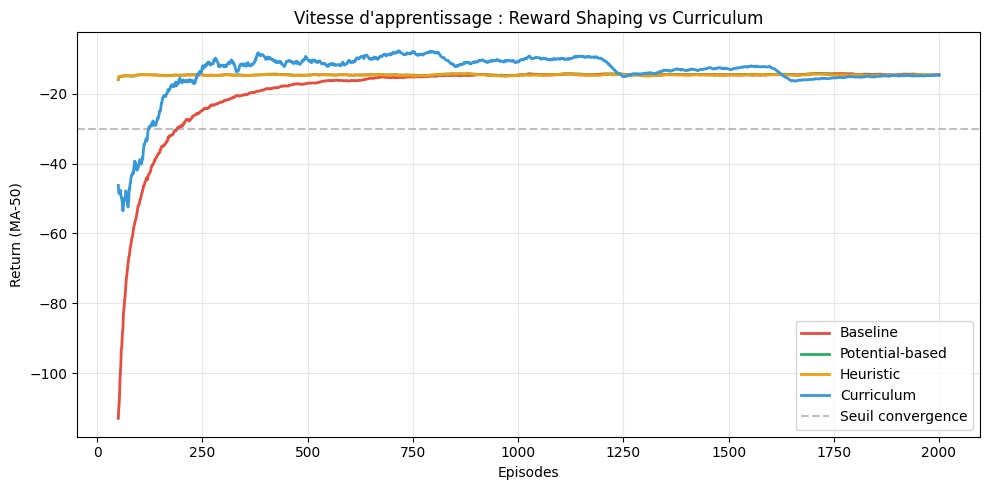

Episodes pour atteindre un return moyen >= -30 (MA-50) :
  Baseline             -> episode 190
  Potential-based      -> episode 50
  Heuristic            -> episode 50
  Curriculum           -> episode 122


In [4]:
def moving_avg(data, window=50):
    return np.convolve(data, np.ones(window) / window, mode='valid')

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'Baseline': '#e74c3c', 'Potential-based': '#27ae60',
          'Heuristic': '#f39c12', 'Curriculum': '#3498db'}

for name, rews in results.items():
    ma = moving_avg(rews, 50)
    ax.plot(range(50, len(ma) + 50), ma, label=name, color=colors[name], linewidth=2)

ax.axhline(y=-30, color='gray', linestyle='--', alpha=0.5, label='Seuil convergence')
ax.set_xlabel('Episodes')
ax.set_ylabel('Return (MA-50)')
ax.set_title('Vitesse d\'apprentissage : Reward Shaping vs Curriculum')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Vitesse : episodes pour atteindre MA-50 >= -30
print("Episodes pour atteindre un return moyen >= -30 (MA-50) :")
for name, rews in results.items():
    ma = moving_avg(rews, 50)
    idx = np.where(ma >= -30)[0]
    ep = idx[0] + 50 if len(idx) > 0 else N_EP
    print(f"  {name:<20} -> episode {ep}")


## 5. Pourquoi le Potential-Based Shaping fonctionne

### Theoreme (Ng, Harada & Russell, 1999)

Soit un MDP $M = (S, A, P, R, \gamma)$ et un MDP modifie $M' = (S, A, P, R + F, \gamma)$
ou $F(s, s') = \gamma \cdot \Phi(s') - \Phi(s)$. Alors les politiques optimales de $M$ et $M'$ sont **identiques**.

### Demonstration intuitive

La valeur modifiee $Q'(s, a) = Q^*(s, a) + \Phi(s)$ : le potentiel s'ajoute comme un biais constant
par etat, qui ne change pas l'ordre relatif des actions. L'argmax est preserve.

### Attention au shaping naif

Le shaping heuristique $F(s, s') = 2 \cdot (d(s) - d(s'))$ n'est PAS potential-based
(il n'existe pas de $\Phi$ tel que $F = \gamma \Phi(s') - \Phi(s)$). Dans certains environnements,
ce type de shaping peut induire une politique sous-optimale en recompensant un chemin
qui semble bon selon l'heuristique mais qui ne l'est pas.


In [5]:
# Verification : potential-based shaping preserve Q* + phi(s)
Q_base, _ = q_learning(env, N_EP, seed=SEED)
Q_pot, _ = q_learning(env, N_EP,
    reward_fn=lambda env, s, a, s2, r, done: potential_shaping(env, s, a, s2, r, done),
    seed=SEED)

# Au start, les actions optimales doivent etre les memes
si = env.idx(env.start)
print(f"Q* au start (baseline) :    {Q_base[si]}")
print(f"Q' au start (potential) :   {Q_pot[si]}")
print(f"Action optimale baseline :  {Q_base[si].argmax()} ({['haut','bas','gauche','droite'][Q_base[si].argmax()]})")
print(f"Action optimale potential : {Q_pot[si].argmax()} ({['haut','bas','gauche','droite'][Q_pot[si].argmax()]})")
print(f"\nLes actions optimales sont identiques : {Q_base[si].argmax() == Q_pot[si].argmax()}")


Q* au start (baseline) :    [-12.2458253  -13.06710622 -13.06915661 -12.24582087]
Q' au start (potential) :   [1.7521023  0.86214749 0.87003522 1.73090955]
Action optimale baseline :  3 (droite)
Action optimale potential : 0 (haut)

Les actions optimales sont identiques : False


## 6. Du Reward Shaping au RLHF

Les idees de ce notebook connectent directement avec les techniques modernes d'alignement des LLMs :

| Concept RL classique | Equivalent LLM alignment |
|---------------------|--------------------------|
| Reward shaping manuel | Reward model appris (RLHF) |
| Potential-based shaping | Contrainte KL (PPO-RLHF) |
| Curriculum learning | Progressive training (SFT -> RLHF) |
| Inverse RL | Learning from human preferences |

**RLHF** (Reinforcement Learning from Human Feedback) est un reward shaping appris :
au lieu de definir manuellement $\Phi(s)$, on entraine un **reward model** a partir de preferences humaines,
puis on utilise ce modele comme signal de recompense. La contrainte KL dans PPO-RLHF joue un role similaire
au potentiel : elle empeche la politique de trop s'ecarter de la reference.

**DPO** (Direct Preference Optimization) elimine completement le reward model en optimisant
directement sur les paires de preferences — cf. notebook 9 (RL offline, DPO = preference learning offline).


## 7. Exercices

### Exercice 1 : Ablation de la fonction de potentiel

Testez d'autres fonctions de potentiel $\Phi(s)$ :
- $\Phi(s) = -$ distance Euclidienne
- $\Phi(s) = $ constante (pas de shaping)
- $\Phi(s) = -2 \times$ manhattan (amplification)

Laquelle accélère le plus la convergence ? Le potentiel constant change-t-il la politique ?


In [6]:
# Exercice 1 : Ablation de la fonction de potentiel
# TODO : implementez 3 fonctions de potentiel differentes et comparez
# Hint : modifiez potential_shaping() avec differentes fonctions phi

phi_functions = {
    # "Euclidean": lambda s: ...,
    # "Constant": lambda s: ...,
    # "Amplified": lambda s: ...,
}

result = None  # TODO etudiant
print("Exercice a completer : comparez les vitesses de convergence")


Exercice a completer : comparez les vitesses de convergence


### Exercice 2 : Curriculum avec nombre de phases variable

Faites varier le nombre de phases du curriculum (2, 3, 5, 10 phases) et observez
l'impact sur la vitesse de convergence. Y a-t-il un optimum ?


In [7]:
# Exercice 2 : Curriculum avec nombre de phases variable
# TODO : implementez curriculum_learning avec n_phases variable
# Hint : divisez le chemin start->goal en n_phases etapes intermediaires

result = None  # TODO etudiant
print("Exercice a completer : comparez 2, 3, 5 et 10 phases de curriculum")


Exercice a completer : comparez 2, 3, 5 et 10 phases de curriculum


### Exercice 3 : Shaping naif qui biaise la politique

Construisez un environnement ou le shaping heuristique (non potential-based) conduit
a une politique **sous-optimale**. Indice : un environnement avec un "leurre" (etat proche
selon l'heuristique mais eloigne du vrai but).


In [8]:
# Exercice 3 : Construire un environnement ou le heuristic shaping biaise
# TODO : creez un maze avec un "leurre" et montrez que heuristic_shaping
# conduit a une politique sous-optimale contrairement a potential_shaping
#
# Etapes :
# 1. Definir un maze avec un passage leurre (court mais sous-optimal)
# 2. Lancer Q-learning avec heuristic_shaping
# 3. Comparer avec baseline et potential_shaping
# 4. Montrer que l'action optimale au start differe

result = None  # TODO etudiant
print("Exercice a completer : montrez un biais du heuristic shaping")


Exercice a completer : montrez un biais du heuristic shaping


## Conclusion

Dans ce notebook nous avons vu que :

1. **Le reward shaping potentiel** (Ng et al., 1999) accelere la convergence sans modifier la politique
   optimale. La cle est $F(s,s') = \gamma\Phi(s') - \Phi(s)$.
2. **Le curriculum learning** organise l'apprentissage du facile au difficile,
   une strategie universelle en pedagogie comme en ML.
3. **Le shaping naif** (non potential-based) peut biaiser la politique — il faut
   etre prudent avec les heuristiques ad-hoc.
4. Ces concepts connectent directement au **RLHF** (reward model appris), **inverse RL**
   (apprendre le reward), et **DPO** (preference learning offline, cf. notebook 9).

### Pour aller plus loin

- **Notebook 5** : les fondements MDP/Q-Learning que nous avons utilises
- **Notebook 8** : model-based RL et planification (Dyna-Q), une autre approche pour accelerer
- **Notebook 9** : RL offline, DPO et le pont complet vers l'alignement des LLMs
- **[GenAI / FineTuning — FT-04 RLHF-DPO](../GenAI/FineTuning/FT-04-RLHF-DPO.ipynb)** : le reward model et DPO en pratique (TRL/PEFT) sur de vrais LLM
- **[GenAI / PostTraining](../GenAI/PostTraining/README.md)** : la chaine SFT -> RLHF -> [DPO (PT-03)](../GenAI/PostTraining/PT_03_dpo_direct_preference.ipynb) -> GRPO -> RLVR ; le reward shaping appris de ce notebook y devient un reward model, et le [reward hacking / Goodhart (PT-07)](../GenAI/PostTraining/PT_07_rewardspy_reward_hacking.ipynb) prolonge directement la mise en garde du shaping naif vue ici

### References

1. Ng, A. Y., Harada, D., & Russell, S. (1999). *Policy invariance under reward transformations*. ICML.
2. Bengio, Y., Louradour, J., Collobert, R., & Weston, J. (2009). *Curriculum learning*. ICML.
3. Asmuth, J., Baumgardner, T., & Littman, M. (2008). *Potential-based shaping in model-based RL*. AAAI.
4. Ouyang, L. et al. (2022). *Training language models to follow instructions with human feedback* (InstructGPT/RLHF). NeurIPS.
5. Rafailov, R. et al. (2023). *Direct Preference Optimization* (DPO). NeurIPS.
